[[18  0]
 [ 0 42]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        42

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

🔍 Predicción para condiciones nuevas:
   Humedad: 80%
   Presión: 995 hPa
   ¿Lloverá?: Sí ☔


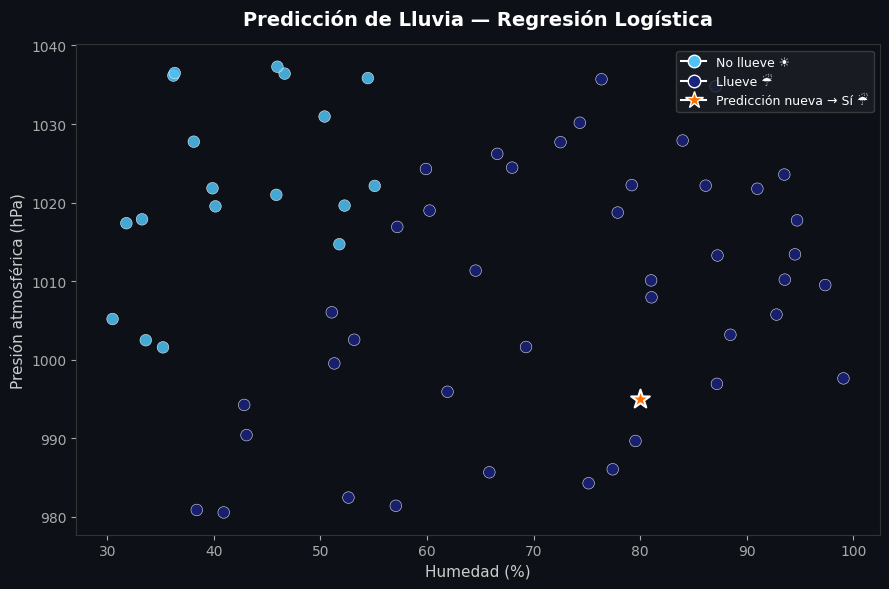


📊 Gráfico guardado como 'weather_prediction.png'


In [3]:
#Predicción meteorológica con gráfico

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Clase que representa un registro meteorológico
class WeatherRecord:
    def __init__(self, humidity, pressure, will_rain):
        self.humidity = humidity
        self.pressure = pressure
        self.will_rain = will_rain

    def to_vector(self):
        return [self.humidity, self.pressure]


# Generador de datos sintéticos
class WeatherDataGenerator:
    def __init__(self, num_samples=200):
        self.num_samples = num_samples

    def generate(self):
        np.random.seed(42)
        records = []

        humidity_values = np.random.uniform(30, 100, self.num_samples)
        pressure_values = np.random.uniform(980, 1040, self.num_samples)

        for humidity, pressure in zip(humidity_values, pressure_values):
            rain_prob = (humidity - 50) * 0.03 - (pressure - 1010) * 0.02
            rain_prob = 1 / (1 + np.exp(-rain_prob))
            will_rain = 1 if rain_prob >= 0.5 else 0
            records.append(WeatherRecord(humidity, pressure, will_rain))

        return records


# Clase que entrena el modelo de regresión logística
class WeatherRainClassifier:
    def __init__(self):
        self.model = LogisticRegression()

    def fit(self, records):
        X = [r.to_vector() for r in records]
        y = [r.will_rain for r in records]
        self.model.fit(X, y)

    def predict(self, humidity, pressure):
        return self.model.predict([[humidity, pressure]])[0]

    def evaluate(self, records):
        X = [r.to_vector() for r in records]
        y = [r.will_rain for r in records]
        y_pred = self.model.predict(X)
        print(confusion_matrix(y, y_pred))
        print(classification_report(y, y_pred))


# Clase para ejecutar el ejemplo completo
class WeatherRainPredictionExample:
    def run(self):
        # 1. Generar datos
        generator = WeatherDataGenerator(num_samples=200)
        records = generator.generate()

        # 2. Dividir en entrenamiento y prueba
        train_records, test_records = train_test_split(
            records, test_size=0.3, random_state=42
        )

        # 3. Entrenar el modelo
        classifier = WeatherRainClassifier()
        classifier.fit(train_records)

        # 4. Evaluar el modelo
        classifier.evaluate(test_records)

        # 5. Predicción para condiciones nuevas
        humidity_new = 80
        pressure_new = 995
        prediction = classifier.predict(humidity_new, pressure_new)
        result = "Sí ☔" if prediction == 1 else "No ☀️"

        print("🔍 Predicción para condiciones nuevas:")
        print(f"   Humedad: {humidity_new}%")
        print(f"   Presión: {pressure_new} hPa")
        print(f"   ¿Lloverá?: {result}")

        # 6. Gráfico de datos de prueba
        humidities = [r.humidity for r in test_records]
        pressures = [r.pressure for r in test_records]
        labels = [r.will_rain for r in test_records]

        colors = ["#4fc3f7" if label == 0 else "#1a237e" for label in labels]

        fig, ax = plt.subplots(figsize=(9, 6))
        fig.patch.set_facecolor("#0d1117")
        ax.set_facecolor("#0d1117")

        scatter = ax.scatter(
            humidities,
            pressures,
            c=colors,
            s=70,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.4,
        )

        # Punto de predicción nueva
        ax.scatter(
            humidity_new,
            pressure_new,
            color="#ff6f00",
            s=200,
            zorder=5,
            edgecolors="white",
            linewidths=1.5,
            marker="*",
            label=f"Nueva condición ({humidity_new}%, {pressure_new} hPa) → {result}",
        )

        # Leyenda manual
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#4fc3f7',
                   markersize=9, label='No llueve ☀️'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#1a237e',
                   markersize=9, label='Llueve ☔'),
            Line2D([0], [0], marker='*', color='w', markerfacecolor='#ff6f00',
                   markersize=13, label=f'Predicción nueva → {result}'),
        ]
        ax.legend(
            handles=legend_elements,
            loc="upper right",
            facecolor="#1c1f26",
            edgecolor="#444",
            labelcolor="white",
            fontsize=9,
        )

        ax.set_xlabel("Humedad (%)", color="#cccccc", fontsize=11)
        ax.set_ylabel("Presión atmosférica (hPa)", color="#cccccc", fontsize=11)
        ax.set_title(
            "Predicción de Lluvia — Regresión Logística",
            color="white",
            fontsize=14,
            fontweight="bold",
            pad=14,
        )
        ax.tick_params(colors="#aaaaaa")
        for spine in ax.spines.values():
            spine.set_edgecolor("#333333")

        plt.tight_layout()
        plt.savefig("/home/casa/weather_prediction.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("\n📊 Gráfico guardado como 'weather_prediction.png'")


# Ejecutar ejemplo
example = WeatherRainPredictionExample()
example.run()

In [2]:
pwd

'/home/casa'